# 22 · Unsupervised pain phenotypes

Two complementary unsupervised views:

1. **Baseline k-means on the enriched feature set** (demographics, pre-anchor pain-trajectory features, biomarkers, genetic flags). Does the data separate into interpretable pain-risk phenotypes? If so, do DBS effects differ by phenotype?
2. **Longitudinal k-means on pain trajectories** (NP1PAIN values at 6-month bins from −24 to +48 months). Does clustering on the pain time-course itself reveal distinct dynamics that correlate with DBS exposure or baseline biology?

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(cluster); library(factoextra); library(purrr); library(forcats)
})
enriched <- readRDS(file.path(OUT_OBJ, "patient_anchor_features_enriched.rds"))
cat("Enriched n:", nrow(enriched), "\n")

Enriched n: 642 


## 1. Baseline k-means phenotypes

In [2]:
feat_cols <- c("age_at_visit","ageonset","duration_yrs","BMI",
               "updrs3_score","NHY","LEDD","scopa","gds","stai","ess","rem",
               "pre_mean","pre_max","pre_sd","pre_slope",
               "mean_putamen","mean_caudate","asyn","NFL_CSF","abeta")
feat_cols <- intersect(feat_cols, names(enriched))

median_impute <- function(x){ x[is.na(x)] <- stats::median(x, na.rm=TRUE); x }
X <- enriched %>% dplyr::select(dplyr::all_of(feat_cols)) %>%
  dplyr::mutate(dplyr::across(dplyr::everything(), median_impute))
X <- apply(as.matrix(X), 2, function(col) {
  q <- stats::quantile(col, c(0.02, 0.98), na.rm = TRUE)
  pmin(pmax(col, q[1]), q[2])
})
Xs <- scale(X)
cat("Design:", nrow(Xs), "x", ncol(Xs), " (", length(feat_cols), "features)\n")

Design: 642 x 19  ( 19 features)


In [3]:
set.seed(42)
eval_k <- function(K) {
  km <- stats::kmeans(Xs, centers = K, nstart = 50, iter.max = 1000)
  sil <- cluster::silhouette(km$cluster, dist(Xs))
  tibble::tibble(K = K, sil = mean(sil[, 3]),
                 withinss = km$tot.withinss,
                 size_min = min(km$size),
                 size_max = max(km$size))
}
res <- purrr::map_dfr(2:6, eval_k)
print(res)
save_table(res, "kmeans_baseline_K_selection")

# A tibble: 5 × 5
      K    sil withinss size_min size_max
  <int>  <dbl>    <dbl>    <int>    <int>
1     2 0.142    10912.      232      410
2     3 0.0761   10173.      163      259
3     4 0.0817    9542.      103      235
4     5 0.0859    9104.       67      220
5     6 0.0858    8722.       48      203


In [4]:
best_K <- res %>% dplyr::filter(size_min >= 0.05 * nrow(Xs)) %>%
  dplyr::slice_max(sil, n = 1) %>% dplyr::pull(K)
cat("Best K by Silhouette (with size constraint):", best_K, "\n")
set.seed(42)
km_best <- stats::kmeans(Xs, centers = best_K, nstart = 200, iter.max = 2000)
enriched$cluster_base <- km_best$cluster
print(enriched %>% dplyr::count(cluster_base, will_receive_dbs) %>%
        tidyr::pivot_wider(names_from = will_receive_dbs, values_from = n, values_fill = 0))

Best K by Silhouette (with size constraint): 2 


# A tibble: 2 × 3
  cluster_base `FALSE` `TRUE`
         <int>   <int>  <int>
1            1     395     15
2            2     180     52


In [5]:
# Characterise clusters by median values
prof <- enriched %>% dplyr::select(cluster_base, dplyr::all_of(feat_cols)) %>%
  dplyr::group_by(cluster_base) %>%
  dplyr::summarise(dplyr::across(dplyr::everything(), ~ round(stats::median(.x, na.rm = TRUE), 2)),
                   n = dplyr::n(), .groups = "drop") %>%
  dplyr::relocate(cluster_base, n)
print(prof, width = Inf)
save_table(prof, "kmeans_baseline_profiles")

# Pain worsening rate and mean Δ pain by cluster × arm
perf <- enriched %>% dplyr::mutate(arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS")) %>%
  dplyr::group_by(cluster_base, arm) %>%
  dplyr::summarise(n = dplyr::n(), mean_delta = mean(delta, na.rm = TRUE),
                   pct_worsen = mean(worsened, na.rm = TRUE), .groups = "drop")
print(perf, n = 20)
save_table(perf, "kmeans_baseline_pain_by_cluster_arm")

# A tibble: 2 × 21
  cluster_base     n age_at_visit ageonset duration_yrs   BMI updrs3_score   NHY
         <int> <int>        <dbl>    <dbl>        <dbl> <dbl>        <dbl> <dbl>
1            1   410         65.1     61.6         0.48  26.6           20     2
2            2   232         66.7     59.7         1.07  26.6           26     2
   LEDD scopa   gds  stai pre_mean pre_max pre_sd pre_slope mean_putamen
  <dbl> <dbl> <dbl> <dbl>    <dbl>   <dbl>  <dbl>     <dbl>        <dbl>
1     0     8     1  54       0.5        1   0            0         0.76
2   300    16     4  74.5     1.53       2   0.51         0         0.64
  mean_caudate  asyn NFL_CSF abeta
         <dbl> <dbl>   <dbl> <dbl>
1         1.88 1338.    97.7  793.
2         1.73 1373.    79.4  850.


# A tibble: 4 × 5
  cluster_base arm           n mean_delta pct_worsen
         <int> <chr>     <int>      <dbl>      <dbl>
1            1 DBS          15     0.188       0.133
2            1 Never-DBS   395     0.228       0.162
3            2 DBS          52     0.0290      0.173
4            2 Never-DBS   180    -0.242       0.144


In [6]:
# Formal test: arm × cluster interaction on worsening
dat_int <- enriched %>% dplyr::mutate(dbs = as.integer(will_receive_dbs),
                                      cluster_f = factor(cluster_base))
f_main <- worsened ~ dbs + cluster_f + age_at_visit + duration_yrs + pre_mean
f_int  <- worsened ~ dbs * cluster_f + age_at_visit + duration_yrs + pre_mean
fit_main <- stats::glm(f_main, data = dat_int, family = "binomial")
fit_int  <- stats::glm(f_int,  data = dat_int, family = "binomial")
cat("LR test — does DBS effect differ by baseline cluster?\n")
print(stats::anova(fit_main, fit_int, test = "Chisq"))
save_object(enriched, "patient_anchor_features_clustered")

LR test — does DBS effect differ by baseline cluster?


Analysis of Deviance Table

Model 1: worsened ~ dbs + cluster_f + age_at_visit + duration_yrs + pre_mean
Model 2: worsened ~ dbs * cluster_f + age_at_visit + duration_yrs + pre_mean
  Resid. Df Resid. Dev Df Deviance Pr(>Chi)
1       621     522.69                     
2       620     522.53  1  0.15799    0.691


## 2. Longitudinal k-means on pain trajectories

In [7]:
# Build a wide trajectory matrix: patients × time bins
rel <- load_full_ppmi_rel_patient_anchor() %>%
  dedup_earliest_per_bin()

bins <- seq(-24, 48, by = 6)
wide <- rel %>% dplyr::filter(months %in% bins, !is.na(NP1PAIN)) %>%
  dplyr::select(PATNO, months, NP1PAIN) %>%
  tidyr::pivot_wider(names_from = months, values_from = NP1PAIN, names_prefix = "m")
# Require at least 4 non-missing time points per patient
wide <- wide %>% dplyr::mutate(n_obs = rowSums(!is.na(dplyr::select(., dplyr::starts_with("m"))))) %>%
  dplyr::filter(n_obs >= 4)
cat("Patients with ≥ 4 trajectory points:", nrow(wide), "\n")

# Impute missing by patient-specific linear interp, then fill edges with median
impute_row <- function(v) {
  if (sum(!is.na(v)) < 2) return(v)
  x <- seq_along(v)
  fit <- stats::lm(v ~ x, na.action = na.exclude)
  pred <- stats::predict(fit, data.frame(x = x))
  dplyr::coalesce(v, pred)
}
M <- as.matrix(wide %>% dplyr::select(dplyr::starts_with("m")))
M_imp <- t(apply(M, 1, impute_row))
# Replace any remaining NA with column median
for (j in seq_len(ncol(M_imp))) M_imp[is.na(M_imp[, j]), j] <- stats::median(M_imp[, j], na.rm = TRUE)
cat("Imputed trajectory matrix:", dim(M_imp), "\n")

Patients with ≥ 4 trajectory points: 181 


Imputed trajectory matrix: 181 9 


In [8]:
set.seed(42)
eval_kt <- function(K) {
  km <- stats::kmeans(M_imp, centers = K, nstart = 50, iter.max = 1000)
  sil <- cluster::silhouette(km$cluster, dist(M_imp))
  tibble::tibble(K = K, sil = mean(sil[, 3]),
                 size_min = min(km$size), size_max = max(km$size))
}
res_t <- purrr::map_dfr(2:5, eval_kt)
print(res_t)
save_table(res_t, "kmeans_traj_K_selection")

# A tibble: 4 × 4
      K   sil size_min size_max
  <int> <dbl>    <int>    <int>
1     2 0.413       57      124
2     3 0.306       39       80
3     4 0.333       17       78
4     5 0.322        8       69


In [9]:
best_Kt <- res_t %>% dplyr::filter(size_min >= 0.05 * nrow(M_imp)) %>%
  dplyr::slice_max(sil, n = 1) %>% dplyr::pull(K)
cat("Trajectory-clustering K:", best_Kt, "\n")
set.seed(42)
km_t <- stats::kmeans(M_imp, centers = best_Kt, nstart = 200, iter.max = 2000)
wide$traj_cluster <- km_t$cluster

# Merge arm and baseline
arm_info <- enriched %>% dplyr::select(PATNO, will_receive_dbs, delta, worsened)
traj_dat <- wide %>% dplyr::inner_join(arm_info, by = "PATNO") %>%
  dplyr::mutate(arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))
print(traj_dat %>% dplyr::count(traj_cluster, arm) %>%
        tidyr::pivot_wider(names_from = arm, values_from = n, values_fill = 0))
save_object(traj_dat, "trajectory_cluster_membership")

Trajectory-clustering K: 2 


# A tibble: 2 × 3
  traj_cluster   DBS `Never-DBS`
         <int> <int>       <int>
1            1    38          78
2            2    17          39


Warning message:
“There was 1 warning in `dplyr::mutate()`.
ℹ In argument: `months = as.integer(gsub("m", "", bin))`.
Caused by warning:
! NAs introduced by coercion”


Warning message:
“Removed 18 rows containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 18 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 18 rows containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 18 rows containing missing values or values outside the scale range
(`geom_point()`).”


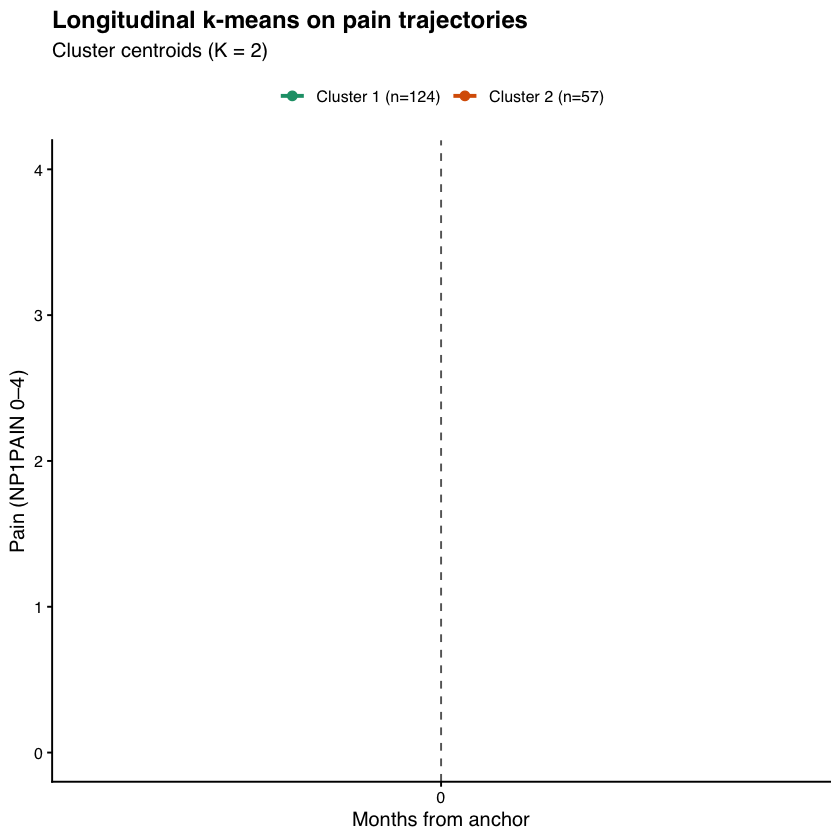

In [10]:
# Plot cluster centroids (trajectories)
centroids <- as.data.frame(km_t$centers) %>% tibble::rownames_to_column("cluster") %>%
  tidyr::pivot_longer(-cluster, names_to = "bin", values_to = "NP1PAIN") %>%
  dplyr::mutate(months = as.integer(gsub("m", "", bin)),
                cluster = paste0("Cluster ", cluster))
cluster_sizes <- as.numeric(km_t$size)
centroids <- centroids %>% dplyr::left_join(
  tibble::tibble(cluster = paste0("Cluster ", seq_along(cluster_sizes)),
                 n = cluster_sizes),
  by = "cluster"
) %>% dplyr::mutate(cluster_lab = sprintf("%s (n=%d)", cluster, n))

p_cent <- ggplot(centroids, aes(months, NP1PAIN, colour = cluster_lab)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 1.1) + geom_point(size = 2.3) +
  scale_colour_brewer(palette = "Dark2", name = NULL) +
  scale_x_continuous(breaks = seq(-24, 48, 12)) +
  scale_y_continuous(breaks = 0:4, limits = c(0, 4)) +
  labs(title = "Longitudinal k-means on pain trajectories",
       subtitle = sprintf("Cluster centroids (K = %d)", best_Kt),
       x = "Months from anchor", y = "Pain (NP1PAIN 0–4)") +
  theme_classic(base_size = 12, base_family = "Helvetica") +
  theme(plot.title = element_text(face = "bold"), legend.position = "top")
p_cent
save_fig(p_cent, "Figure17_traj_cluster_centroids", width = 8, height = 4.6)

In [11]:
# Does DBS exposure differ across trajectory clusters?
ctab <- table(traj_dat$traj_cluster, traj_dat$arm)
print(ctab)
print(round(prop.table(ctab, margin = 1), 3))
print(stats::chisq.test(ctab))

# Mean Δ pain per cluster × arm
perf_t <- traj_dat %>% dplyr::group_by(traj_cluster, arm) %>%
  dplyr::summarise(n = dplyr::n(), mean_delta = mean(delta, na.rm = TRUE),
                   pct_worsen = mean(worsened, na.rm = TRUE), .groups = "drop")
print(perf_t)
save_table(perf_t, "kmeans_traj_pain_by_cluster_arm")

   
    DBS Never-DBS
  1  38        78
  2  17        39


   
      DBS Never-DBS
  1 0.328     0.672
  2 0.304     0.696



	Pearson's Chi-squared test with Yates' continuity correction

data:  ctab
X-squared = 0.020162, df = 1, p-value = 0.8871



# A tibble: 4 × 5
  traj_cluster arm           n mean_delta pct_worsen
         <int> <chr>     <int>      <dbl>      <dbl>
1            1 DBS          38   0.222        0.211 
2            1 Never-DBS    78  -0.000127     0.103 
3            2 DBS          17  -0.317        0.0588
4            2 Never-DBS    39   0.454        0.308 
